In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Dict, Any, List
import torch
import torch.nn.functional as F
import ray
import gymnasium as gym
from ray.rllib.algorithms.algorithm import Algorithm
import os
import sys
from copy import deepcopy

# Add project root to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.rllib_single_agent_wrapper import RLLibSingleAgentWrapper
from src.env.peer_group_environment import PeerGroupEnvironment
from ray import tune


In [2]:
# 1. Load RLlib PPO checkpoints
checkpoint_paths = [
    Path("../checkpoints/PPO_checkpoints/ppo_balanced_by_effort_iter0099_mrl50_djwnaafk_11-05-09-06_eval_na_periodic_seed1").resolve(),
    Path("../checkpoints/PPO_checkpoints/ppo_balanced_by_effort_iter0099_mrl50_gvr49cx9_12-05-02-40_eval_na_periodic_seed2").resolve(),
    Path("../checkpoints/PPO_checkpoints/ppo_balanced_by_effort_iter0099_mrl50_064xj18g_12-05-16-21_eval_na_periodic_seed3").resolve(),
    Path("../checkpoints/PPO_checkpoints/ppo_balanced_by_effort_iter0099_mrl50_szarbkte_13-05-20-23_eval_na_periodic_seed4").resolve(),
    Path("../checkpoints/PPO_checkpoints/ppo_balanced_by_effort_iter0099_mrl50_vsy7vsv9_14-05-07-22_eval_na_periodic_seed5").resolve()
]

for checkpoint_path in checkpoint_paths:
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint path {checkpoint_path} not found.")

# Initialize Ray if not already
if not ray.is_initialized():
    ray.init(ignore_reinit_error=True, local_mode=True)

# Training configuration values
env_config = {
    "start_agents": 100,
    "max_agents": 400,
    "max_steps": 600,
    "max_peer_group_size": 40,
    "n_groups": 10,
    "n_projects_per_step": 1,
    "max_projects_per_agent": 8,
    "reward_mode": "by_effort",
}

ENV_NAME = "peer_group_single_agent_fixed_population"

def env_creator(config):
    env = PeerGroupEnvironment(
        start_agents=env_config["start_agents"],
        max_agents=env_config["max_agents"],
        max_steps=env_config["max_steps"],
        max_peer_group_size=env_config["max_peer_group_size"],
        n_groups=env_config["n_groups"],
        n_projects_per_step=env_config["n_projects_per_step"],
        max_projects_per_agent=env_config["max_projects_per_agent"],
        reward_mode=env_config["reward_mode"],
    )
    return RLLibSingleAgentWrapper(env)

tune.register_env(ENV_NAME, env_creator)

# Create wrapper instance for feature index map
dummy_env = PeerGroupEnvironment(
    start_agents=env_config["start_agents"],
    max_agents=env_config["max_agents"],
    max_steps=env_config["max_steps"],
    max_peer_group_size=env_config["max_peer_group_size"],
    n_groups=env_config["n_groups"],
    n_projects_per_step=env_config["n_projects_per_step"],
    max_projects_per_agent=env_config["max_projects_per_agent"],
    reward_mode=env_config["reward_mode"]
)
wrapper_instance = RLLibSingleAgentWrapper(dummy_env)

# Build feature index map
feature_index = wrapper_instance.get_feature_index_map()
print(f"Feature index map built with {len(feature_index)} features.")

# Load all checkpoints
algos = []
policies = []

for i, checkpoint_path in enumerate(checkpoint_paths, 1):
    try:
        algo = Algorithm.from_checkpoint(str(checkpoint_path))
        print(f"Checkpoint {i}/5 restored successfully from {checkpoint_path.name}")
        algos.append(algo)

        policy = algo.get_policy()
        policies.append(policy)

        if i == 1:
            print(f"Policy Observation Space: {policy.observation_space}")
            print(f"Policy Action Space: {policy.action_space}")
            expected_obs_size = policy.observation_space.shape[0]
            print(f"Expected observation size: {expected_obs_size}")
    except Exception as e:
        print(f"Failed to load checkpoint {i}: {e}")
        raise e

E:\PythonProjects\Hochschule\Game_of_Science_RL\.venv\Lib\site-packages\ray\_private\client_mode_hook.py:104: FutureWarning: `local_mode` is an experimental feature that is no longer maintained and will be removed in the near future. For debugging consider using the Ray distributed debugger.
  return func(*args, **kwargs)
2026-06-07 12:22:11,674	INFO worker.py:2013 -- Started a local Ray instance.
E:\PythonProjects\Hochschule\Game_of_Science_RL\.venv\Lib\site-packages\ray\_private\worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
E:\PythonProjects\Hochschule\Game_of_Science_RL\.venv\Lib\site-packages\ray\rllib\algorithms\algorithm.py:527: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warnin

Feature index map built with 451 features.
:job_id:01000000
:actor_name:RolloutWorker
TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451
:actor_name:RolloutWorker
TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451
:actor_name:RolloutWorker


:actor_name:RolloutWorker
:actor_name:RolloutWorker


TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451
:actor_name:RolloutWorker


:actor_name:RolloutWorker
:actor_name:RolloutWorker


...

TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451
:actor_name:RolloutWorker
TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451


:actor_name:RolloutWorker


TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451
:actor_name:RolloutWorker
TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451


:actor_name:RolloutWorker
:actor_name:RolloutWorker


:actor_name:RolloutWorker
TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451
TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451
Checkpoint 5/5 restored successfully from ppo_balanced_by_effort_iter0099_mrl50_vsy7vsv9_14-05-07-22_eval_na_periodic_seed5


In [3]:
# 2. Generate fresh observations for each checkpoint
print("\n--- Generating fresh observations for all 5 checkpoints ---")

all_checkpoint_observations = []  # List of (checkpoint_idx, observations) tuples
seeds = range(501, 521)
max_obs_per_checkpoint = 1000

for checkpoint_idx, algo in enumerate(algos, 1):
    print(f"\nCheckpoint {checkpoint_idx}/5:")
    fresh_observations = []
    
    for seed in seeds:
        obs, info = wrapper_instance.reset(seed=seed)
        fresh_observations.append(obs)
        
        terminated = truncated = False
        while not (terminated or truncated):
            # Use policy to get action
            action = algo.compute_single_action(obs, policy_id="default_policy")
            obs, reward, terminated, truncated, info = wrapper_instance.step(action)
            
            assert obs.shape[0] == expected_obs_size, f"Obs size mismatch: {obs.shape[0]} != {expected_obs_size}"
            fresh_observations.append(obs)
            
            if len(fresh_observations) >= max_obs_per_checkpoint:
                break
        if len(fresh_observations) >= max_obs_per_checkpoint:
            break
    
    print(f"  Collected {len(fresh_observations)} observations")
    all_checkpoint_observations.append((checkpoint_idx, fresh_observations))

total_obs = sum(len(obs_list) for _, obs_list in all_checkpoint_observations)
print(f"\nTotal observations collected: {total_obs}")


--- Generating fresh observations for all 5 checkpoints ---

Checkpoint 1/5:
TRAIN obs_vec size: 451
TRAIN expected_obs_size: 451
  Collected 1000 observations

Checkpoint 2/5:
  Collected 1000 observations

Checkpoint 3/5:
  Collected 1000 observations

Checkpoint 4/5:
  Collected 1000 observations

Checkpoint 5/5:
  Collected 1000 observations

Total observations collected: 5000


In [4]:
# 3. Corrected flat-vector sensitivity functions

def get_head_slices(action_space):
    """
    Build correct logit slices for a Gymnasium Dict action space.

    Important fix:
    - Discrete(n) uses n logits.
    - MultiDiscrete(nvec) uses sum(nvec) logits, not prod(shape).

    Example:
    MultiDiscrete([2] * 40) represents 40 binary categorical decisions.
    It therefore needs 80 logits: 2 logits per peer.
    """
    if not isinstance(action_space, gym.spaces.Dict):
        raise TypeError(f"Expected gym.spaces.Dict action space, got {type(action_space)}: {action_space}")

    slices = {}
    start = 0

    # Preserve the action-space order defined by the wrapper/RLlib.
    for head, space in action_space.spaces.items():
        if isinstance(space, gym.spaces.Discrete):
            size = int(space.n)
        elif isinstance(space, gym.spaces.MultiDiscrete):
            size = int(np.sum(space.nvec))
        else:
            raise NotImplementedError(f"Unsupported action space for head '{head}': {space}")

        slices[head] = {
            "start": start,
            "end": start + size,
            "size": size,
            "space": space,
        }
        start += size

    return slices


def _probabilities_from_head_logits(head_logits, space):
    """
    Convert one action-head logit vector into probabilities used for sensitivity.

    For Discrete heads, the full softmax probability vector is used.
    For MultiDiscrete heads, logits are split into one categorical distribution
    per sub-action. For binary sub-actions, only P(action=1) is used because
    this directly represents the collaboration intent probability.
    """
    if isinstance(space, gym.spaces.Discrete):
        return F.softmax(head_logits, dim=0)

    if isinstance(space, gym.spaces.MultiDiscrete):
        sizes = [int(n) for n in space.nvec]
        parts = torch.split(head_logits, sizes)

        if len(parts) != len(sizes):
            raise ValueError(
                f"MultiDiscrete split failed: expected {len(sizes)} parts, got {len(parts)}. "
                f"sizes={sizes}, logits={head_logits.shape}"
            )

        probs = []
        for part in parts:
            p = F.softmax(part, dim=0)

            # Binary sub-action: use probability of action 1.
            if part.shape[0] == 2:
                probs.append(p[1].reshape(1))
            else:
                # Generic fallback for non-binary MultiDiscrete sub-actions.
                probs.append(p.reshape(-1))

        return torch.cat(probs)

    raise NotImplementedError(f"Unsupported action space: {space}")


def diagnose_logit_splitting(policy, obs_vec):
    """
    Return diagnostics that verify whether the action-space logit split matches
    the actual policy output size.
    """
    model = policy.model
    model.eval()

    obs_tensor = torch.tensor(obs_vec, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        logits, _ = model({"obs": obs_tensor}, [], torch.tensor([1]))

    head_slices = get_head_slices(policy.action_space)
    expected_logits = max(meta["end"] for meta in head_slices.values())
    actual_logits = int(logits.shape[-1])

    return {
        "action_space": policy.action_space,
        "head_slices": head_slices,
        "expected_logits": expected_logits,
        "actual_logits": actual_logits,
        "logits_shape": tuple(logits.shape),
        "is_valid": expected_logits == actual_logits,
    }


def compute_flat_logit_sensitivity(policy, obs_vec, feature_idx, epsilon=1e-3):
    """
    Compute local policy sensitivity to a small perturbation in one observation feature.

    The metric is mean absolute probability change for each action head.
    This is a local policy-output sensitivity, not a causal reward effect.
    """
    model = policy.model
    model.eval()

    obs_orig = torch.tensor(obs_vec, dtype=torch.float32).unsqueeze(0)
    obs_pert = obs_orig.clone()
    obs_pert[0, feature_idx] += epsilon

    with torch.no_grad():
        logits_orig, _ = model({"obs": obs_orig}, [], torch.tensor([1]))
        logits_pert, _ = model({"obs": obs_pert}, [], torch.tensor([1]))

    head_slices = get_head_slices(policy.action_space)
    expected_logits = max(meta["end"] for meta in head_slices.values())
    actual_logits = int(logits_orig.shape[-1])

    if expected_logits != actual_logits:
        formatted_slices = {
            head: {"start": meta["start"], "end": meta["end"], "size": meta["size"], "space": str(meta["space"])}
            for head, meta in head_slices.items()
        }
        raise ValueError(
            f"Logit split mismatch: expected {expected_logits}, got {actual_logits}. "
            f"Computed head slices: {formatted_slices}"
        )

    results = {}
    for head, meta in head_slices.items():
        start = meta["start"]
        end = meta["end"]
        space = meta["space"]

        l_orig = logits_orig[0, start:end]
        l_pert = logits_pert[0, start:end]

        p_orig = _probabilities_from_head_logits(l_orig, space)
        p_pert = _probabilities_from_head_logits(l_pert, space)

        delta_probs = p_pert - p_orig
        results[head] = {
            "mean_abs_delta_prob": torch.mean(torch.abs(delta_probs)).item(),
            "n_probabilities": int(p_orig.numel()),
        }

    return results


In [ ]:
# 4. Build feature list with only the specified features from observation

def build_specified_feature_list(feature_index, max_peers=40):
    """
    Build a feature list with only these observation features:
    - peer_group (40 values) -> actually called observation.peer_group.0 to .39
    - peer_reputation (40 values) -> observation.peer_reputation.0 to .39  
    - accumulated_rewards (1 value)
    - peer_centroids (80 values) -> observation.peer_centroids.0 to .79 (flattened 40x2)
    - peer_h_index (1 value) -> might not exist
    - self_centroid (2 values) -> might not exist, check for self_centroids instead
    - self_centroids (2 values) -> observation.self_centroids.0 and .1
    - age (1 value)

    Total: up to 127 features
    """
    features_to_analyze = {}

    # Global features - check if they exist
    if "observation.age" in feature_index:
        features_to_analyze["age"] = "observation.age"
    if "observation.accumulated_rewards" in feature_index:
        features_to_analyze["accumulated_rewards"] = "observation.accumulated_rewards"
    if "observation.peer_h_index" in feature_index:
        features_to_analyze["peer_h_index"] = "observation.peer_h_index"

    # Self centroids - check various naming conventions
    for i in range(2):
        # Try self_centroids first
        key = f"observation.self_centroids.{i}"
        if key in feature_index:
            features_to_analyze[f"self_centroids_{i}"] = key
        # Fallback to self_centroid
        elif f"observation.self_centroid.{i}" in feature_index:
            features_to_analyze[f"self_centroid_{i}"] = f"observation.self_centroid.{i}"

    # Peer group and reputation features
    for i in range(max_peers):
        peer_group_key = f"observation.peer_group.{i}"
        if peer_group_key in feature_index:
            features_to_analyze[f"peer_{i}_group"] = peer_group_key

        peer_rep_key = f"observation.peer_reputation.{i}"
        if peer_rep_key in feature_index:
            features_to_analyze[f"peer_{i}_reputation"] = peer_rep_key

    # Peer centroids - these are flattened in the observation vector
    # peer_centroids is shape (40, 2) but gets flattened to indices 0-79
    # So we access them as observation.peer_centroids.0, .1, .2, ... .79
    for flat_idx in range(max_peers * 2):
        peer_centroid_key = f"observation.peer_centroids.{flat_idx}"
        if peer_centroid_key in feature_index:
            peer_idx = flat_idx // 2
            coord_idx = flat_idx % 2
            features_to_analyze[f"peer_{peer_idx}_centroid_{coord_idx}"] = peer_centroid_key

    return features_to_analyze


print("\n--- Verifying corrected logit splitting before sensitivity analysis ---")
first_policy = policies[0]
first_obs = all_checkpoint_observations[0][1][0]
diagnostics = diagnose_logit_splitting(first_policy, first_obs)
print(f"Expected logits: {diagnostics['expected_logits']}")
print(f"Actual logits:   {diagnostics['actual_logits']}")
if not diagnostics["is_valid"]:
    raise ValueError(f"Invalid logit split diagnostics: {diagnostics}")
print("Logit split validation passed.")

print("\n--- Building specified feature list ---")
features_to_analyze = build_specified_feature_list(feature_index)

print(f"\nTotal features to analyze: {len(features_to_analyze)}")

# Show feature breakdown
print("\nFeature breakdown:")
global_features = [k for k in features_to_analyze.keys() if k in ["age", "accumulated_rewards", "peer_h_index"]]
self_centroid_features = [k for k in features_to_analyze.keys() if k.startswith("self_centroid")]
peer_group_features = [k for k in features_to_analyze.keys() if k.endswith("_group")]
peer_reputation_features = [k for k in features_to_analyze.keys() if k.endswith("_reputation")]
peer_centroid_features = [k for k in features_to_analyze.keys() if "_centroid_" in k and k.startswith("peer_")]

print(f"  Global: {len(global_features)}")
print(f"  Self centroids: {len(self_centroid_features)}")
print(f"  Peer group: {len(peer_group_features)}")
print(f"  Peer reputation: {len(peer_reputation_features)}")
print(f"  Peer centroids: {len(peer_centroid_features)}")

# 5. Run Sensitivity Analysis for all checkpoints with specified features
print("\n--- Running Sensitivity Analysis for all checkpoints ---")
sensitivity_results = []
epsilon = 1e-3

for checkpoint_idx, fresh_observations in all_checkpoint_observations:
    policy = policies[checkpoint_idx - 1]
    print(f"\nCheckpoint {checkpoint_idx}/5: Analyzing {len(features_to_analyze)} features...")
    
    feature_count = 0
    for label, feature_name in features_to_analyze.items():
        if feature_name not in feature_index:
            print(f"  Warning: {feature_name} not found in feature index map. Skipping.")
            continue
            
        idx = feature_index[feature_name]
        feature_count += 1
        
        if feature_count % 20 == 0 or feature_count == len(features_to_analyze):
            print(f"  Progress: {feature_count}/{len(features_to_analyze)} features...")
        
        for obs_id, obs in enumerate(fresh_observations):
            res = compute_flat_logit_sensitivity(policy, obs, idx, epsilon=epsilon)
            for head, metrics in res.items():
                sensitivity_results.append({
                    "checkpoint": checkpoint_idx,
                    "observation_id": obs_id,
                    "feature": label,
                    "head": head,
                    "sensitivity": metrics["mean_abs_delta_prob"] / epsilon,
                    "n_probabilities": metrics["n_probabilities"],
                })

df_sensitivity = pd.DataFrame(sensitivity_results)

# 6. Aggregate results
# First average over observations per checkpoint. Then compute mean/std across checkpoints.
print("\n--- Aggregating results ---")
checkpoint_sensitivity = (
    df_sensitivity
    .groupby(["checkpoint", "feature", "head"], as_index=False)["sensitivity"]
    .mean()
)

agg_sensitivity_all = checkpoint_sensitivity.groupby(["feature", "head"])["sensitivity"].mean().unstack()
agg_sensitivity_std = checkpoint_sensitivity.groupby(["feature", "head"])["sensitivity"].std().unstack()

print("\nTop 15 features by mean sensitivity (across all action heads):")
overall_mean = agg_sensitivity_all.mean(axis=1).sort_values(ascending=False)
print(overall_mean.head(15))

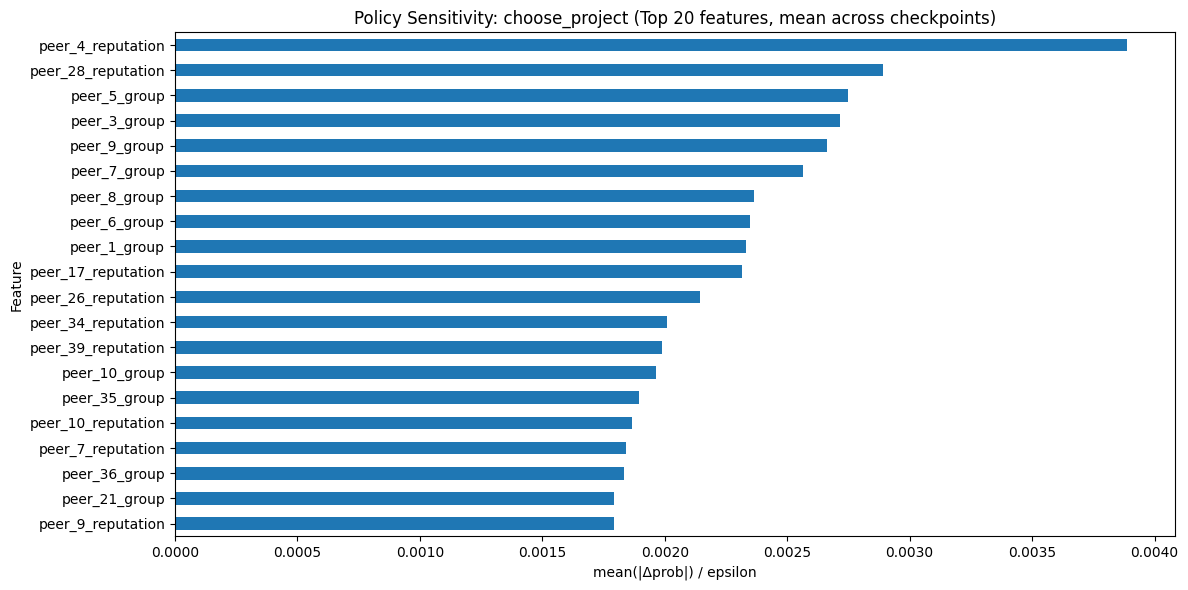

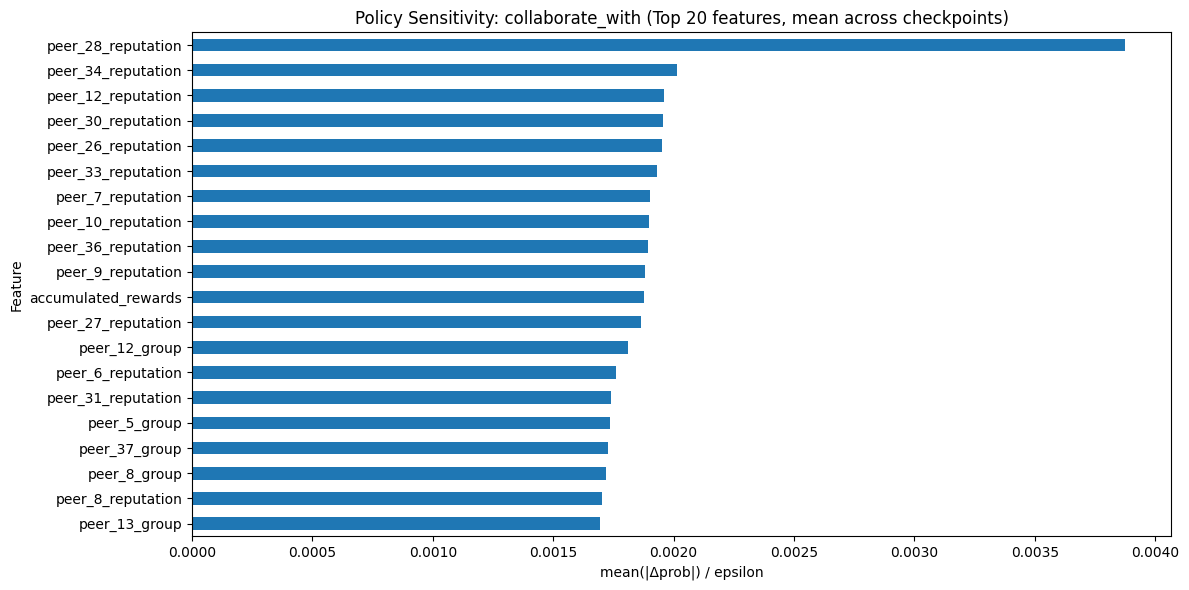

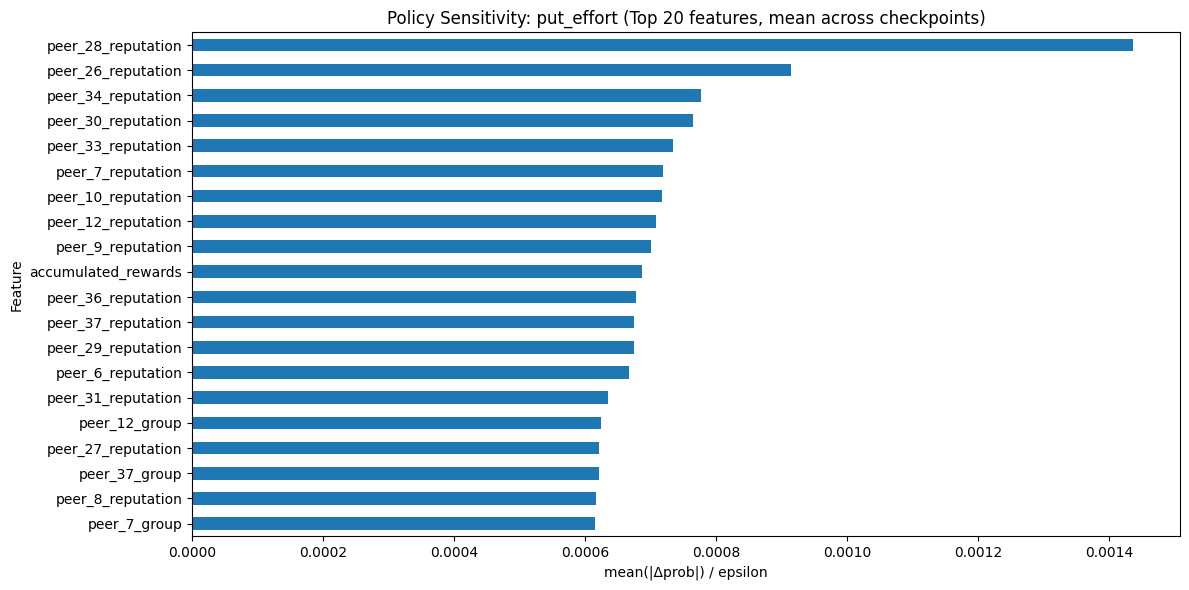


--- Variation analysis across checkpoints ---

Standard deviation of checkpoint-level mean sensitivity:
head                 choose_project  collaborate_with  put_effort
feature                                                          
accumulated_rewards        0.000292          0.000236    0.000098
age                        0.000350          0.000163    0.000054
peer_0_group               0.000279          0.000168    0.000061
peer_0_reputation          0.000351          0.000277    0.000082
peer_10_group              0.000389          0.000113    0.000086
...                             ...               ...         ...
peer_8_reputation          0.000733          0.000196    0.000151
peer_9_group               0.000767          0.000151    0.000033
peer_9_reputation          0.000437          0.000237    0.000082
self_centroids_0           0.000424          0.000078    0.000104
self_centroids_1           0.000459          0.000186    0.000048

[84 rows x 3 columns]


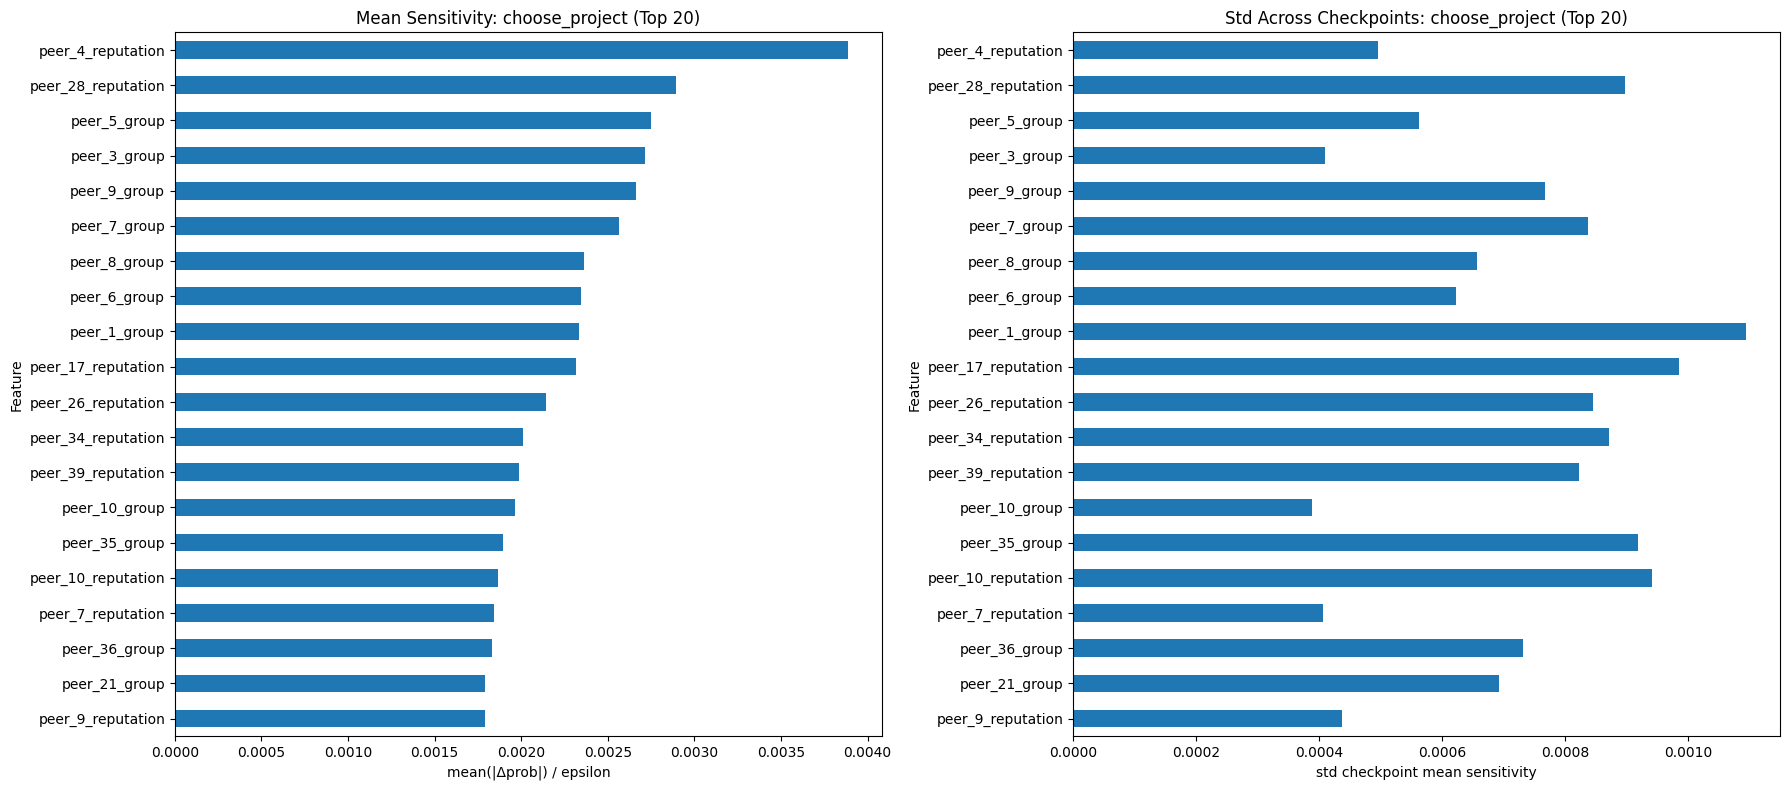

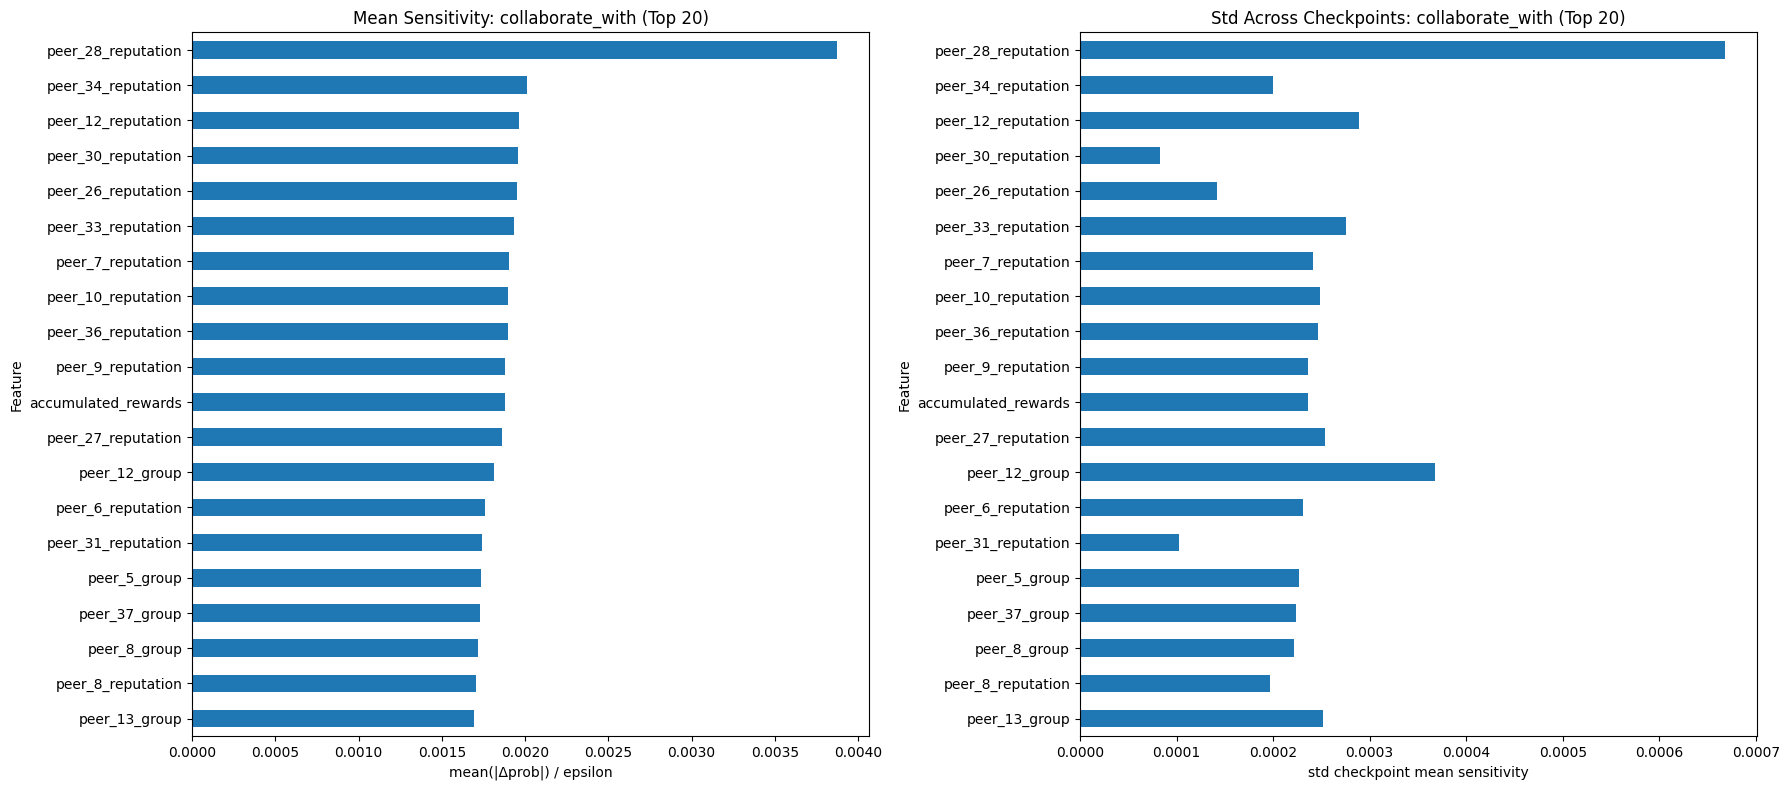

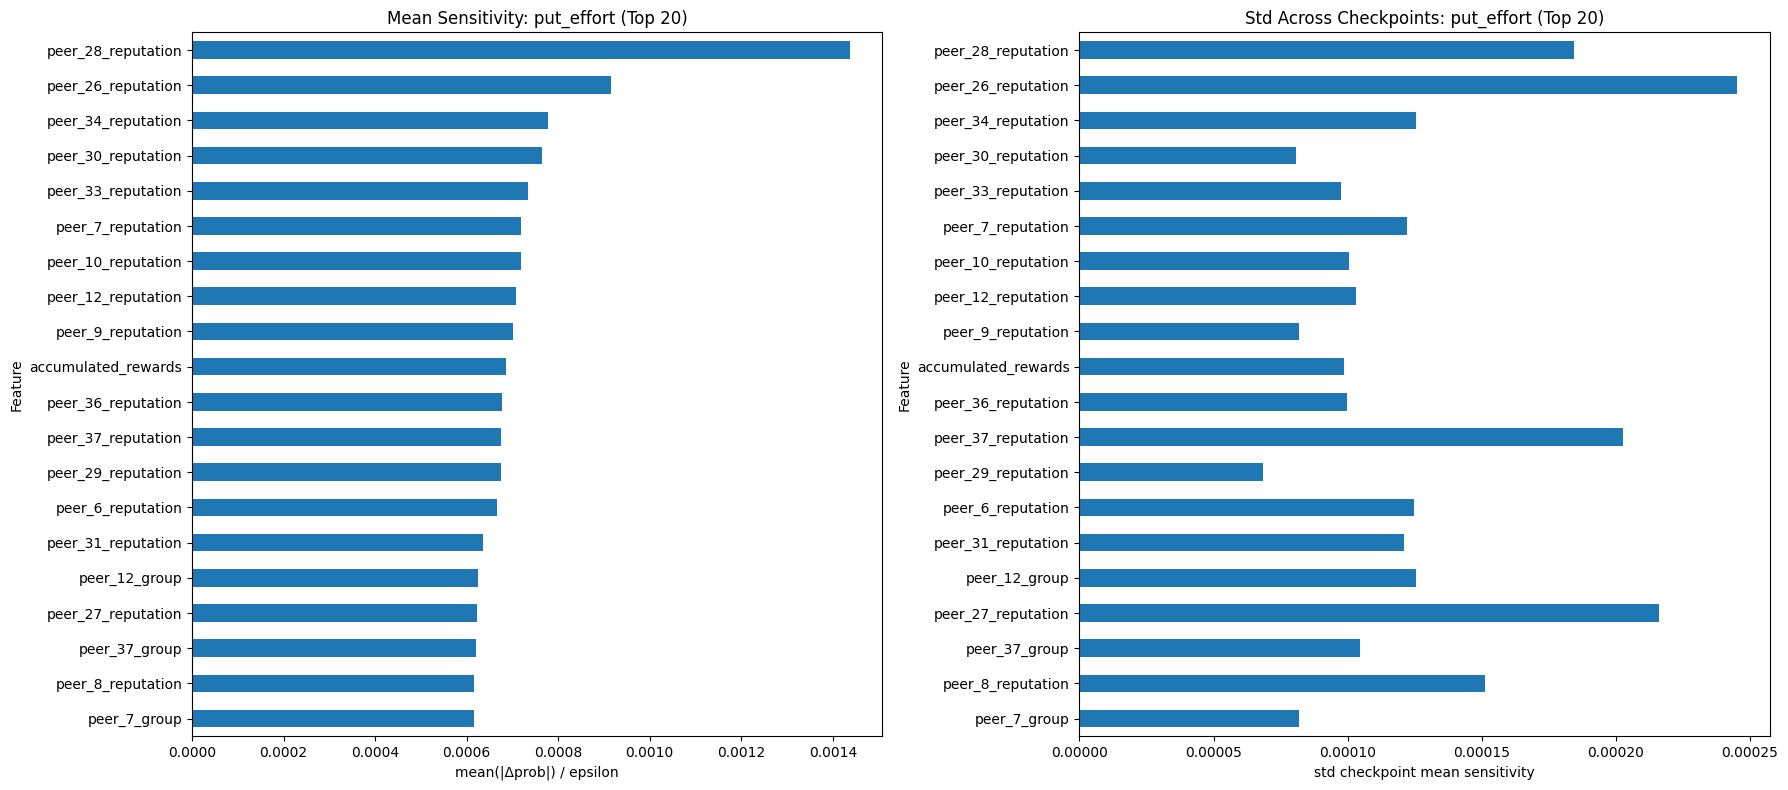

In [12]:
# 6. Visualization: Top features per head (aggregated across checkpoints)
heads = agg_sensitivity_all.columns
top_n = 20  # Show top 20 features

for head in heads:
    plt.figure(figsize=(12, 6))

    agg_sensitivity_all[head] \
        .sort_values(ascending=False) \
        .head(top_n) \
        .plot(kind="barh")

    plt.title(f"Policy Sensitivity: {head} (Top {top_n} features, mean across checkpoints)")
    plt.xlabel("mean(|Δprob|) / epsilon")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()  # Highest at top

    plt.tight_layout()
    plt.show()

# Comparison plot showing variation across checkpoints - Top 20 features
print("\n--- Variation analysis across checkpoints ---")
print("\nStandard deviation of checkpoint-level mean sensitivity:")
print(agg_sensitivity_std)

for head in heads:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Mean sensitivity across checkpoints - Top 20
    top_features = agg_sensitivity_all[head].sort_values(ascending=False).head(top_n)
    top_features.plot(kind="barh", ax=ax1)
    ax1.set_title(f"Mean Sensitivity: {head} (Top {top_n})")
    ax1.set_xlabel("mean(|Δprob|) / epsilon")
    ax1.set_ylabel("Feature")
    ax1.invert_yaxis()  # Highest at top
    
    # Standard deviation across checkpoint-level means - same top 20 features
    feature_order = top_features.index
    agg_sensitivity_std[head] \
        .reindex(feature_order) \
        .plot(kind="barh", ax=ax2)
    ax2.set_title(f"Std Across Checkpoints: {head} (Top {top_n})")
    ax2.set_xlabel("std checkpoint mean sensitivity")
    ax2.set_ylabel("Feature")
    ax2.invert_yaxis()  # Highest at top
    
    plt.tight_layout()
    plt.show()

In [10]:
# 7. Comprehensive tabular results for all features
print("=" * 80)
print("COMPREHENSIVE SENSITIVITY RESULTS - SPECIFIED OBSERVATION FEATURES")
print("=" * 80)

# Statistics are computed on checkpoint-level means, not directly on all observations.
summary_table = checkpoint_sensitivity.groupby(["feature", "head"]).agg({
    "sensitivity": ["mean", "std", "min", "max", "count"]
}).round(6)

summary_table.columns = ["Mean", "Std Dev Across Checkpoints", "Min", "Max", "N_checkpoints"]
print("\nDetailed statistics per feature and action head:")
print(summary_table)

# Pivot table: Mean sensitivity.
print("\n" + "=" * 80)
print("MEAN SENSITIVITY (mean across checkpoint-level means)")
print("=" * 80)
pivot_mean = agg_sensitivity_all.round(6)
print(pivot_mean)

# Pivot table: Std Dev across checkpoints.
print("\n" + "=" * 80)
print("STANDARD DEVIATION (across checkpoint-level means)")
print("=" * 80)
pivot_std = agg_sensitivity_std.round(6)
print(pivot_std)

# Overall ranking by mean sensitivity aggregated across all heads.
print("\n" + "=" * 80)
print("OVERALL FEATURE RANKING (mean across all action heads)")
print("=" * 80)
overall_ranking = pivot_mean.mean(axis=1).sort_values(ascending=False)
print(overall_ranking.round(6))

# Per action head ranking.
print("\n" + "=" * 80)
print("TOP 10 FEATURES PER ACTION HEAD")
print("=" * 80)
heads = pivot_mean.columns
for head in heads:
    print(f"\n{head.upper()}:")
    top10 = pivot_mean[head].sort_values(ascending=False).head(10)
    for i, (feature, value) in enumerate(top10.items(), 1):
        print(f"  {i}. {feature:30s} {value:.6f}")

# Export to DataFrame for thesis tables / further analysis.
print("\n" + "=" * 80)
print("SUMMARY TABLE (sorted by mean sensitivity)")
print("=" * 80)

def _safe_values(df, column):
    if column in df.columns:
        return df[column].values
    return np.full(len(df.index), np.nan)

summary_export = pd.DataFrame({
    "Feature": pivot_mean.index,
    "choose_project_mean": _safe_values(pivot_mean, "choose_project"),
    "choose_project_std": _safe_values(pivot_std, "choose_project"),
    "collaborate_with_mean": _safe_values(pivot_mean, "collaborate_with"),
    "collaborate_with_std": _safe_values(pivot_std, "collaborate_with"),
    "put_effort_mean": _safe_values(pivot_mean, "put_effort"),
    "put_effort_std": _safe_values(pivot_std, "put_effort"),
})
summary_export["overall_mean"] = summary_export[[
    "choose_project_mean", "collaborate_with_mean", "put_effort_mean"
]].mean(axis=1)
summary_export = summary_export.sort_values("overall_mean", ascending=False)
print(summary_export.to_string(index=False))

# Save corrected CSV for specified features only
output_path = Path("sensitivity_analysis_results_specified_features.csv")
summary_export.to_csv(output_path, index=False)
print(f"\nResults saved to {output_path.resolve()}")

COMPREHENSIVE SENSITIVITY RESULTS - SPECIFIED OBSERVATION FEATURES

Detailed statistics per feature and action head:
                                          Mean  Std Dev Across Checkpoints  \
feature             head                                                     
accumulated_rewards choose_project    0.001360                    0.000292   
                    collaborate_with  0.001878                    0.000236   
                    put_effort        0.000686                    0.000098   
age                 choose_project    0.001027                    0.000350   
                    collaborate_with  0.001042                    0.000163   
...                                        ...                         ...   
self_centroids_0    collaborate_with  0.001671                    0.000078   
                    put_effort        0.000608                    0.000104   
self_centroids_1    choose_project    0.001640                    0.000459   
                    colla

In [11]:
# 8. Diagnostic output - verification of feature selection
print("=" * 80)
print("DIAGNOSTIC OUTPUT - VERIFICATION OF SPECIFIED FEATURES")
print("=" * 80)

policy = policies[0]
obs_vec = all_checkpoint_observations[0][1][0]
diagnostics = diagnose_logit_splitting(policy, obs_vec)
act_space = diagnostics["action_space"]
head_slices = diagnostics["head_slices"]

print("\n1. ACTION SPACE:")
print(f"   Type: {type(act_space)}")
print(f"   Space: {act_space}")
for head, space in act_space.spaces.items():
    print(f"   - {head}: {space}")
    if isinstance(space, gym.spaces.Discrete):
        print(f"     logits: {space.n}")
    elif isinstance(space, gym.spaces.MultiDiscrete):
        print(f"     nvec length: {len(space.nvec)}")
        print(f"     nvec sum: {int(np.sum(space.nvec))}")

print("\n2. SPECIFIED FEATURES ANALYZED:")
feature_groups = {
    "Global": ["age", "accumulated_rewards", "peer_h_index"],
    "Self centroids": [k for k in features_to_analyze.keys() if k.startswith("self_centroid")],
    "Peer group": [k for k in features_to_analyze.keys() if k.endswith("_group")],
    "Peer reputation": [k for k in features_to_analyze.keys() if k.endswith("_reputation")],
    "Peer centroids": [k for k in features_to_analyze.keys() if "_centroid_" in k and k.startswith("peer_")]
}

for group_name, group_features in feature_groups.items():
    print(f"   {group_name}: {len(group_features)} features")
    if group_name == "Global":
        for f in group_features:
            print(f"     - {f}")

print(f"\n   Total features analyzed: {len(features_to_analyze)}")

print("\n3. EXCLUDED FEATURES:")
print("   The following observation features were NOT analyzed:")
print("   - project_opportunities (all project opportunity features)")
print("   - running_projects (all running project features)")

print("\n4. VALIDATION:")
print(f"   Total expected logits: {diagnostics['expected_logits']}")
print(f"   Actual logits count:   {diagnostics['actual_logits']}")
print(f"   Valid split:           {diagnostics['is_valid']}")

if not diagnostics["is_valid"]:
    raise ValueError("Logit split is still invalid. Do not use the resulting CSV.")

print("\n5. OUTPUT:")
print(f"   Results CSV: {Path('sensitivity_analysis_results_specified_features.csv').resolve()}")
print("\nThis analysis focuses exclusively on peer-related and agent-specific features.")
print("Project-related features have been excluded as requested.")

DIAGNOSTIC OUTPUT - VERIFICATION OF SPECIFIED FEATURES

1. ACTION SPACE:
   Type: <class 'gymnasium.spaces.dict.Dict'>
   Space: Dict('choose_project': Discrete(2), 'collaborate_with': MultiDiscrete([2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2]), 'put_effort': Discrete(9))
   - choose_project: Discrete(2)
     logits: 2
   - collaborate_with: MultiDiscrete([2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2])
     nvec length: 40
     nvec sum: 80
   - put_effort: Discrete(9)
     logits: 9

2. SPECIFIED FEATURES ANALYZED:
   Global: 3 features
     - age
     - accumulated_rewards
     - peer_h_index
   Self centroids: 4 features
   Peer group: 40 features
   Peer reputation: 40 features
   Peer centroids: 80 features

   Total features analyzed: 167

3. EXCLUDED FEATURES:
   The following observation features were NOT analyzed:
   - project_opportunities (all project opportunity features)
   - running_projects (all ru